In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Problem 1
## A:

<Axes: ylabel='Proportion'>

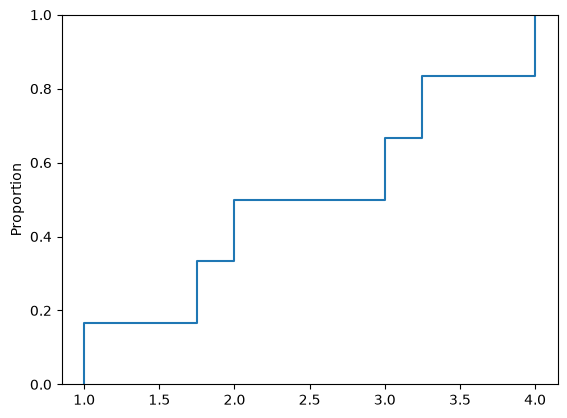

In [2]:
data1 = [1, 1.75, 2, 3, 3.25, 4]

sns.ecdfplot(data1)

## B:

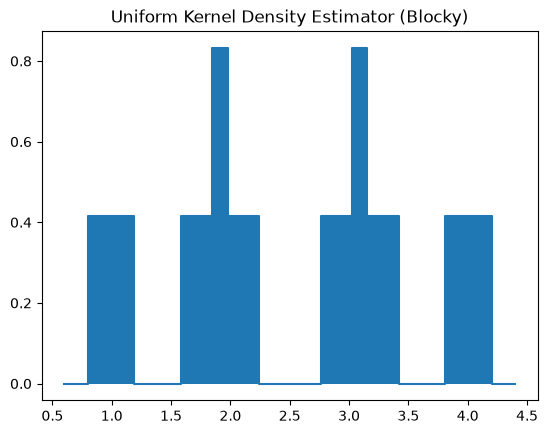

(array([0.6       , 0.73103448, 0.86206897, 0.99310345, 1.12413793,
        1.25517241, 1.3862069 , 1.51724138, 1.64827586, 1.77931034,
        1.91034483, 2.04137931, 2.17241379, 2.30344828, 2.43448276,
        2.56551724, 2.69655172, 2.82758621, 2.95862069, 3.08965517,
        3.22068966, 3.35172414, 3.48275862, 3.6137931 , 3.74482759,
        3.87586207, 4.00689655, 4.13793103, 4.26896552, 4.4       ]),
 array([0.        , 0.        , 0.41666667, 0.41666667, 0.41666667,
        0.        , 0.        , 0.        , 0.41666667, 0.41666667,
        0.83333333, 0.41666667, 0.41666667, 0.        , 0.        ,
        0.        , 0.        , 0.41666667, 0.41666667, 0.83333333,
        0.41666667, 0.41666667, 0.        , 0.        , 0.        ,
        0.41666667, 0.41666667, 0.41666667, 0.        , 0.        ]))

In [12]:
h = 0.2
def kde(X,h_u=0.2, K=30):
    n = len(X)
    X = np.array(X)
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator comparison
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_hat,where='mid')
    plt.fill_between(x_grid,f_hat,step='mid')
    plt.title('Uniform Kernel Density Estimator (Blocky)')
    plt.show()
    return x_grid, f_hat

kde(data1)

## C:

In [9]:
def silverman_bandwidth(X, kernel="uniform"):
    """Silverman's rule-of-thumb bandwidth. `kernel` selects the constant."""
    const = {"uniform": 1.84, "gaussian": 1.06}[kernel]
    return const * np.std(X) * len(X) ** (-0.2)

silverman_bandwidth(data1)

np.float64(1.2991670409500977)

## D:

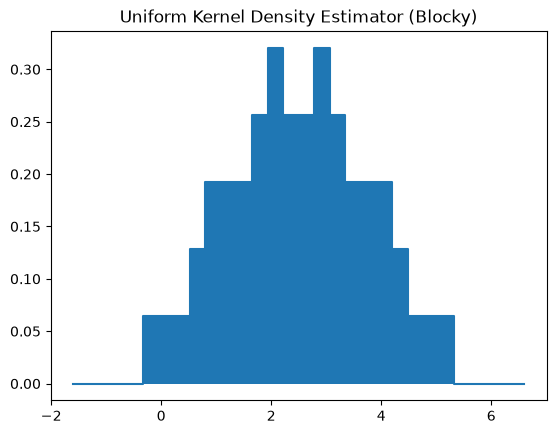

(array([-1.59833408, -1.31569035, -1.03304662, -0.75040289, -0.46775916,
        -0.18511543,  0.0975283 ,  0.38017203,  0.66281576,  0.94545949,
         1.22810322,  1.51074695,  1.79339068,  2.07603441,  2.35867814,
         2.64132186,  2.92396559,  3.20660932,  3.48925305,  3.77189678,
         4.05454051,  4.33718424,  4.61982797,  4.9024717 ,  5.18511543,
         5.46775916,  5.75040289,  6.03304662,  6.31569035,  6.59833408]),
 array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.06414366, 0.06414366, 0.06414366, 0.12828733, 0.19243099,
        0.19243099, 0.19243099, 0.25657465, 0.32071832, 0.25657465,
        0.25657465, 0.32071832, 0.25657465, 0.19243099, 0.19243099,
        0.19243099, 0.12828733, 0.06414366, 0.06414366, 0.06414366,
        0.        , 0.        , 0.        , 0.        , 0.        ]))

In [15]:
kde(data1, h_u=silverman_bandwidth(data1))

## E:

**B and D are different in the sense that D is more uniform throughout while B has sharp jumps where x=value in data. Smaller bandwidth shows more of the patterns in the data, while large bandwidth makes the graph more uniform throughout.**

# Problem 2

## A:

In [26]:
X = np.array([-1, -0.5, 0, 0.5, 1])

def uniform_kde(X, grid, h):
    """f_hat_h(x) on `grid`, uniform kernel. Pure computation, no plotting."""
    X = np.asarray(X)
    n = len(X)
    I = np.abs(grid[:, None] - X[None, :]) < h
    return I.sum(axis=1) / (2 * n * h)

uniform_kde(X, np.array([0.0]), 0.6)

array([0.5])

## B:

In [27]:
from scipy.stats import norm
(2*norm.cdf(0.6)-1)/(2*0.6)

np.float64(0.37624480374987745)

## C:

In [28]:
1/np.sqrt(2*3.14)

np.float64(0.3990434422338111)

## D:

- No, B and C are not perfectly equal, although they are close. What this means for bias is that while the KDE may be biased at this point, it does not mean that there will be bias at every point. 

## E:

In [29]:
(2*norm.cdf(0.1)-1)/(2*0.1)

np.float64(0.3982783727702899)

There is now a smaller gap between E[f_hat_h(0)] and f(0). 

## F:

Yes, f_hat_h is a consistent estimator. This is because the window shrinks as the data grows and maintains a baseline amount of data, so the bias and variance both approach 0 as the function grows. 

## G:

The main thing to consider is the trade off between bias and variance. Large h takes averages over a lot of values and features get smoothed out (low variance with high bias). Small h averages over a small num of values which causes individual observations to be noticed (high variance with low bias). 

# Problem 3

In [33]:
X = np.array([5, 7, 7, 8, 10])
def uniform_kde(X, grid, h):
    X = np.asarray(X)
    grid = np.atleast_1d(grid)
    n = len(X)
    I = np.abs(grid[:, None] - X[None, :]) <= h
    return I.sum(axis=1) / (2 * n * h)
print(uniform_kde(X, np.array([6.0, 6.5, 7.0, 8.0, 8.5]), 1.5))


[0.2        0.26666667 0.2        0.2        0.26666667]


## B:

In [34]:
def gaussian_kde(X, grid, h):
    """f_hat_h(x) on `grid`, Gaussian kernel."""
    X = np.asarray(X)
    n = len(X)
    Z = (grid[:, None] - X[None, :]) / h
    phi = np.exp(-Z**2 / 2) / np.sqrt(2 * np.pi)
    return phi.sum(axis=1) / (n * h)

print(gaussian_kde(X, np.array([6.0, 6.5, 7.0, 8.0, 8.5]), 1.5))


[0.15116668 0.16865731 0.17804448 0.16744524 0.15060231]


## C:

In a, the biggest jumps are from 6.0 to 6.5, 6.5 to 7.0, 8.0 to 8.5. These are 0.067. These jumps represent one 1 point is removed from the window. A uniform kernel forms a shape with flat tops, which are measured with -h and h of x. In b, the largest jump is 0.0175, which is 6.0 to 6.5. 

## D:

I think that in practice, the gaussian kernel may be preferred as visually, it is just easier to interpret in my opinion. The smooth line makes it easier to view the graph. 

# Problem 4

## A:

In [36]:
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
df.head(10)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1


<Axes: xlabel='ejection_fraction', ylabel='Density'>

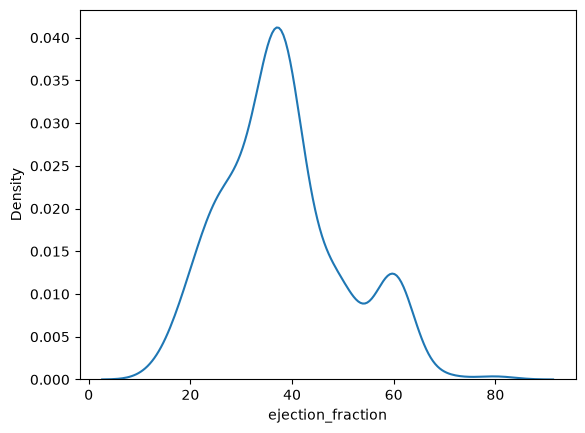

In [37]:
sns.kdeplot(df["ejection_fraction"])


## B:

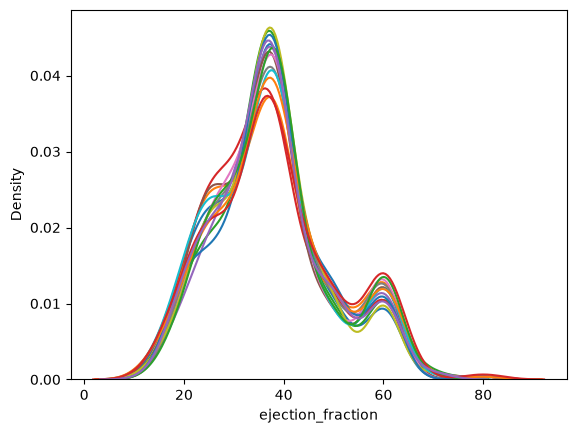

In [ ]:
for i in range(15):
    boot = df.sample(frac=1.0, replace=True)
    sns.kdeplot(boot["ejection_fraction"])



## C:

The first plot is most reliable between an approximate range of around 20 to 45. It seems that the estimated density around these values is the highest, and the second plot supports this observation. There is noticeable variation around the peaks of the 2 bumps, and between around 20 and 30.  